<a href="https://colab.research.google.com/github/2003Himansh/Data-Analysis-Portfolio/blob/main/Financial_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn yfinance

In [ ]:
# Import data analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Stock data API
import yfinance as yf

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style("whitegrid")

In [ ]:
# Download Apple stock data
stock = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

# Display first rows
stock.head()

/tmp/ipykernel_387/1310819081.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214897,24.682230,23.776357,24.671155,212818400
2015-01-05,23.532728,24.064291,23.346682,23.984557,257142000
2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600
2015-01-08,24.781887,24.839473,24.075351,24.192739,237458000


In [ ]:
# Dataset shape
print("Dataset Shape:", stock.shape)

# Dataset info
print(stock.info())

# Summary statistics
print(stock.describe())

Dataset Shape: (2264, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2264 entries, 2015-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2264 non-null   float64
 1   (High, AAPL)    2264 non-null   float64
 2   (Low, AAPL)     2264 non-null   float64
 3   (Open, AAPL)    2264 non-null   float64
 4   (Volume, AAPL)  2264 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 106.1 KB
None
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   2264.000000  2264.000000  2264.000000  2264.000000  2.264000e+03
mean      81.318619    82.142376    80.412963    81.250262  1.237614e+08
std       55.938537    56.511319    55.304136    55.883934  6.818417e+07
min       20.584814    20.887868    20.386578    20.507344  2.404830e+07
25%       32.784029    32.980014    32.60

In [ ]:
# Check missing values
print(stock.isnull().sum())

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


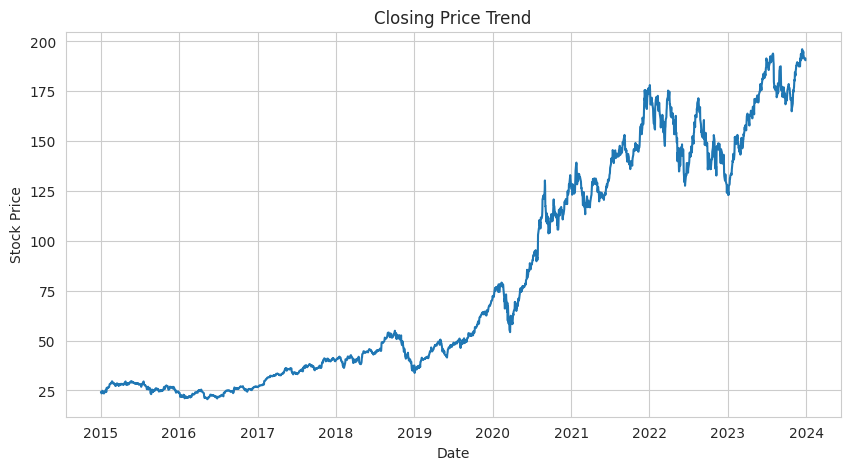

In [ ]:
#chosing price trends
plt.figure(figsize=(10,5))

plt.plot(stock['Close'])

plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.show()

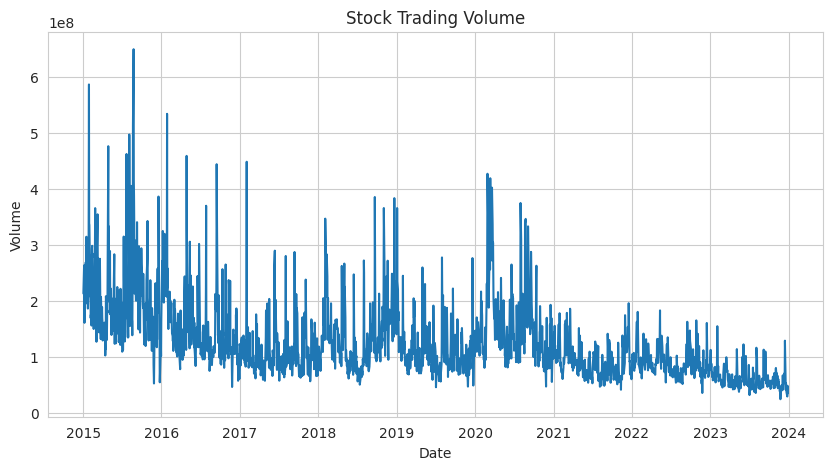

In [ ]:
#trade volume visualization
plt.figure(figsize=(10,5))

plt.plot(stock['Volume'])

plt.title("Stock Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

In [ ]:
# Calculate moving averages
stock['MA20'] = stock['Close'].rolling(20).mean()
stock['MA50'] = stock['Close'].rolling(50).mean()

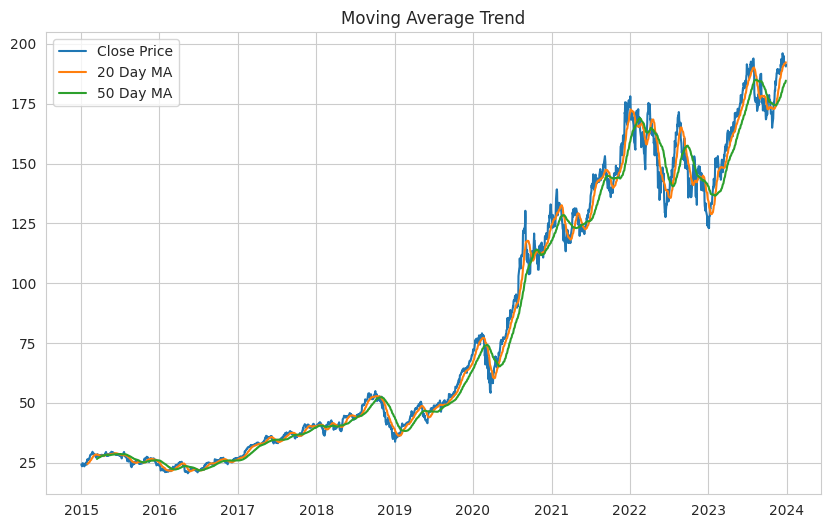

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(stock['Close'], label="Close Price")
plt.plot(stock['MA20'], label="20 Day MA")
plt.plot(stock['MA50'], label="50 Day MA")

plt.title("Moving Average Trend")

plt.legend()

plt.show()

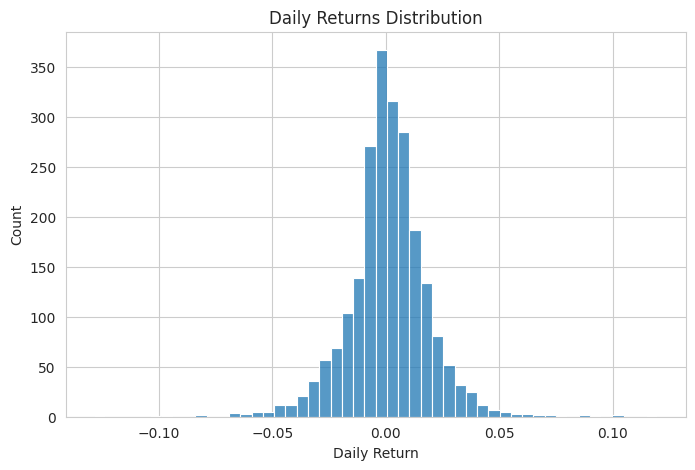

In [ ]:
# Calculate daily returns
stock['Daily Return'] = stock['Close'].pct_change()

plt.figure(figsize=(8,5))

sns.histplot(stock['Daily Return'].dropna(), bins=50)

plt.title("Daily Returns Distribution")

plt.show()

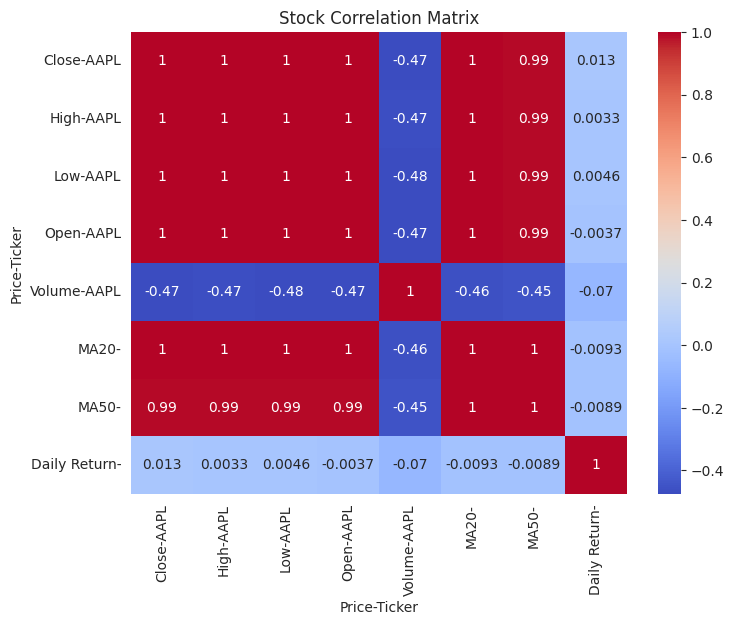

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(stock.corr(), annot=True, cmap="coolwarm")

plt.title("Stock Correlation Matrix")

plt.show()

In [ ]:
# Extract date features
stock['Day'] = stock.index.day
stock['Month'] = stock.index.month
stock['Year'] = stock.index.year

In [ ]:
# Features
X = stock[['Open','High','Low','Volume']]

# Target variable
y = stock['Close']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Linear regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict stock price
predictions = model.predict(X_test)

In [ ]:
# Evaluate model
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 0.3722856377206063
R2 Score: 0.9998873499605736


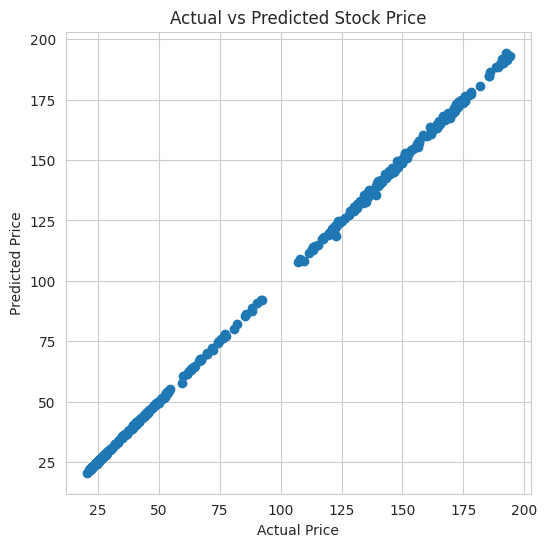

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Stock Price")

plt.show()